# LED Calib for Commissioning of 2x2 run2


In [1]:
%load_ext autoreload

%autoreload 2

from calibWvfms import *

Don't forget to activate the ndlar-flow venv :)

In [2]:
import json

def get_subruns_and_channels(json_path):
    """
    Extract 'data_file', 'subrun' and 'active_chans' values from a JSON file.

    Parameters:
        json_path (str): Path to the JSON file.

    Returns:
    subruns_info (list): subrun infos of the type [[data_file, subrun_number, active_chans], ...] with
            - data_file (str): path to data file
            - subrun_number (int): subrun number
            - active_chans (list) : list of active chans of the type [[adcA, chanB], [adcX, chanY], ...]

    """
    with open(json_path, "r") as f:
        run_info = json.load(f)

    subruns_info = []

    if "subruns" in run_info:
        for subrun in run_info["subruns"]:
            # print(subrun)
            data_file = subrun["data_file"]
            subrun_number = subrun["subrun"]
            active_chans = subrun["active_chans"]

            subruns_info.append([data_file, subrun_number, active_chans])
    else:
        raise KeyError(f"'subruns' key not found in {json_path}")

    return subruns_info

In [3]:
import matplotlib.pyplot as plt

def title_page(text, output):
    # Create a figure with a black background
    fig, ax = plt.subplots(figsize=(6, 4))
    # ax.set_facecolor('black')

    # Add centered white text
    ax.text(0.5, 0.5, text, color='black',
            fontsize=24, ha='center', va='center')

    # Remove axes
    ax.axis('off')

    # Save to PDF
    
    output.savefig()
    plt.close()

In [4]:
import os

def calibrate_sipm(wvfms, subrun_info):
    """
        Function to run through the calibration chain 
            1. Compute the fingerplots
            # 2. Fit the fingerplots
            # 3. Compute the gain
            # 4. Print out the result in a summary pdf

        Summary pdf is made of:
            - 10 waveforms (equally spaced between the first and last events)
            - the fingerplot
            # - the fingerplot with the inital guess and the fitted funciton
            - the wvfms that didnt't make the "int extrem value cut"
    """
    # ~~~~~~~~~~~~~~~~~~ Define general constants ~~~~~~~~~~~~~~~~~~
    signal_window = [110,140] # [ticks]
    Nevents = 19_000

    active_chans = subrun_info[2]
    # ~~~~~~~~~~~~~~~~~~ Loop over the adc and chan (w.r.t the run summary) ~~~~~~~~~~~~~~~~~~
    for adc, chan in active_chans:

        # if adc not in [0, 1]  :
        #     continue

        # adc = 4   #DEBUG
        # chan = 13

        output_dir = os.path.join(wvfms.output_path, f"adc{adc}/chan{chan}")
        os.makedirs(output_dir, exist_ok=True)
        output_pdf = os.path.join(output_dir, f"adc{adc}_chan{chan}_calib_summary.pdf")

        # Output file
        with PdfPages(output_pdf) as summary_pdf:


            print(f" adc: {adc}, chan: {chan}") # DEBUG

            # ~~~~~~~~~~~~~~~~~~ Compute the fingerplot ~~~~~~~~~~~~~~~~~~
            wvfms.compute_fingerplots(Nevent=Nevents, adcs=adc, chans=chan, int_window=signal_window, Nbins=110, mode='integral', nSig=5)
            # Save in output pdf
            title_page("Finger plot",summary_pdf)
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan}', output=summary_pdf)# show=True, plot_name=f'fingerplot_ADC{adc}_chan{chan}.png')

            # ~~~~~~~~~~~~~~~~~~ Fit the fingerplot ~~~~~~~~~~~~~~~~~~
            title_page("Finger plot with p0",summary_pdf)
            wvfms.fit_fingerplots(adc, chan, output=summary_pdf)
            if wvfms.fit_status[adc][chan] == 2:
                # Print some waveforms for examples
                title_page("No initial guess found\nWvfms Examples",summary_pdf)
                Nwvfms = 10
                for event in range(0, Nevents, int(Nevents/Nwvfms)):
                    wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)
                continue

            # ~~~~~~~~~~~~~~~~~~ Compute the gain ~~~~~~~~~~~~~~~~~~
            wvfms.compute_gains(adcs=adc, chans=chan)

            # Save in output pdf
            title_page("Finger plot with\nfitted function and gain",summary_pdf)
            # print(f" in notebook: adc: {adc}, chan: {chan}, status: {wvfms.fit_status[adc][chan]}") # DEBUG
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan} with fitted function', fit_xlim=wvfms.fit_lim[adc][chan], fit_params=wvfms.fitted_params[adc][chan], output=summary_pdf, fit_status=wvfms.fit_status[adc][chan], reduced_chi_squared=wvfms.reduced_chi_squared[adc][chan], gain=wvfms.gains[adc][chan])
            



            # ~~~~~~~~~~~~~~~~~~ Print out summary ~~~~~~~~~~~~~~~~~~

            # Print some waveforms for examples
            title_page("Wvfms Examples",summary_pdf)
            Nwvfms = 10
            for event in range(0, Nevents, int(Nevents/Nwvfms)):
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)


            # Extrem waveforms
            title_page("Cutout waveforms Examples:\n(Integral more than\n5 sig from mean integral value)",summary_pdf)
            # print(f" extrem events: {wvfms.extrem_Int_val[adc][chan]}")
            for event in wvfms.extrem_Int_val[adc][chan]:
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)
    
        # break # DEBUG
    print('~~~~~~~~~~~~ FINISHED ~~~~~~~~~~')



In [5]:
def get_flowed_data(raw_data):
    """
    Extract the filename (without extension) from a full file path.
    Example:
        /path/to/mpd_run_calib_rctl_1923.data → mpd_run_calib_rctl_1923
    """
    raw_filename = os.path.basename(raw_data)       # → 'mpd_run_calib_rctl_1923.data'
    name, _ = os.path.splitext(raw_filename)    # → ('mpd_run_calib_rctl_1923', '.data')

    data_filename = f"{name}.FLOW.hdf5"
    return data_filename

# RUN quick for tests, need to be upgraded in a proper script
(sorry for the mess)

## Define Inputs and output

So first you have to give the path of the run summary json "run_summary_folder" and its name "run_summary".

Then you give the folder where the data are stored "data_folder". What it does is: it looks in the run summary the raw data file name, convert it to a flow file name and look for this file in the "data_folder". So you have to make sure that the run summary have the subrun file name + path set correctly, for example when we runned last night it didn't found the files because it was looking in v02_... and the files were saved in v03_....

> :memo: **Note:** Normally I already checked and put the right path for the data you took this afternoon.

> :memo: **Note2:** The signal window is defined in the function above __calibrate_sipm()__


Finally you can set an output directory where you want the pdf to be printed out

In [6]:
# Directory
run_summary_folder = '/global/cfs/cdirs/dune/www/data/2x2/LRS_run2/cold_commission/v04_LEDscan/'
# run_summary_folder = '/global/homes/s/sallinn/data/2x2_calib/test/LEDcalib_run2/'
run_summary = '20251016_160831_run_summary.json'

data_folder = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v04_LEDscan/'
# Output

output ='/global/homes/s/sallinn/data/2x2_calib/test/20251016_LEDcalib_run2'

## Run the scripts

Then you are ready to start the computations. As a quick overview:  

1. Get the subruns info from the summary json  
2. Convert the raw file name to a flowed file name  
3. Initialize the calibration class  
4. Run the calibration script for subrun 0  

Then it will loop over the next subruns and each time :
1. get the flow data name  
2. load the subrun file in the calib class  
3. run the calibration script  

> :bulb: **Tip:** Remember to appreciate the little things in life, like not working and baking bagels

In [7]:
run_info = get_subruns_and_channels(os.path.join(run_summary_folder,run_summary))

# subrun = 0

# active_chans = run_info[subrun][2]

print("~~~~~~~~~~~~ subrun 0 ~~~~~~~~~~~~")
# print(f"file  :{}")

subrun = run_info[0]
data_file = get_flowed_data(subrun[0])
wvfms = calibWvfms(filedir = data_folder, filename = data_file, output_path=output, log_level='DEBUG')
calibrate_sipm(wvfms, subrun)


for subrun in run_info[1:]:
    print(f"~~~~~~~~~~~~ subrun {subrun[1]} ~~~~~~~~~~~~")
    print(subrun)
    data_file = get_flowed_data(subrun[0])
    # print(data_file)
    wvfms.load_file(filedir = data_folder, filename = data_file)
    calibrate_sipm(wvfms, subrun)

2025-10-16 16:07:17,212 - INFO - set_log_level - Log level changed to DEBUG


~~~~~~~~~~~~ subrun 0 ~~~~~~~~~~~~


2025-10-16 16:07:21,843 - INFO - __init__ - Processing file /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v04_LEDscan/mpd_run_calib_rctl_1960.FLOW.hdf5
2025-10-16 16:07:21,846 - INFO - __init__ - The output path is set to /global/homes/s/sallinn/data/2x2_calib/test/20251016_LEDcalib_run2
2025-10-16 16:07:21,847 - INFO - __init__ - Number of events in the selection: 19949
2025-10-16 16:07:21,850 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1960.FLOW.hdf5 with 19000 events
2025-10-16 16:07:21,851 - DEBUG - compute_fingerplots - ADCs: [0]
2025-10-16 16:07:21,851 - DEBUG - compute_fingerplots - Chans: [4]
2025-10-16 16:07:21,867 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-16 16:07:21,891 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-16 16:07:22,038 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1960.FL

 adc: 0, chan: 4
shape: (19100,)
fit_bounds: [[ 1.06685000e+03 -8.66477273e+05  4.32879816e+02  1.60200000e+02
  -8.65611964e+05  4.32879816e+02  6.36500000e+02 -8.64169782e+05
   4.09598163e+02  1.15800000e+02 -8.63304473e+05  4.09598163e+02
   2.14700000e+02 -8.62006509e+05  3.70916890e+02  8.04000000e+01
  -8.61141200e+05  3.70916890e+02]
 [ 1.23630000e+03 -8.66188836e+05  1.08319954e+03  2.94700000e+02
  -8.65179309e+05  2.70649885e+03  7.38000000e+02 -8.63881345e+05
   1.02499541e+03  2.13300000e+02 -8.62871818e+05  2.56098852e+03
   2.49600000e+02 -8.61718073e+05  9.28292224e+02  1.48400000e+02
  -8.60708545e+05  2.31923056e+03]]
fit_p0: [ 1.12300000e+03 -8.66333055e+05  5.41099770e+02  2.67000000e+02
 -8.65467745e+05  5.41099770e+02  6.70000000e+02 -8.64025564e+05
  5.11997704e+02  1.93000000e+02 -8.63160255e+05  5.11997704e+02
  2.26000000e+02 -8.61862291e+05  4.63646112e+02  1.34000000e+02
 -8.60996982e+05  4.63646112e+02]



status: None


2025-10-16 16:07:22,359 - DEBUG - fit_fingerplots - Fingerplots of ADC 0, chan. 4 fitted
2025-10-16 16:07:22,360 - INFO - fit_fingerplots - The fingerplots of the file mpd_run_calib_rctl_1960.FLOW.hdf5 were fitted.
2025-10-16 16:07:22,373 - DEBUG - plot_fingerplot - Plotting the finger plot


...

 adc: 5, chan: 57
shape: (19100,)
fit_bounds: [[ 3.36300000e+02 -8.32116182e+05  2.78781348e+01  1.81800000e+02
  -8.31834364e+05  2.78781348e+01  3.39150000e+02 -8.31383455e+05
   1.26402243e+03  1.99200000e+02 -8.31214364e+05  1.26402243e+03
   3.39150000e+02 -8.30876182e+05  1.26402243e+03  2.05800000e+02
  -8.30707091e+05  1.26402243e+03]
 [ 3.90400000e+02 -8.32003455e+05  7.06953370e+01  3.34300000e+02
  -8.31665273e+05  1.75238342e+02  3.93700000e+02 -8.31270727e+05
   3.16105608e+03  3.66200000e+02 -8.31045273e+05  7.90114021e+03
   3.93700000e+02 -8.30763455e+05  3.16105608e+03  3.78300000e+02
  -8.30538000e+05  7.90114021e+03]]
fit_p0: [ 3.54000000e+02 -8.32059818e+05  3.48476685e+01  3.03000000e+02
 -8.31778000e+05  3.48476685e+01  3.57000000e+02 -8.31327091e+05
  1.58002804e+03  3.32000000e+02 -8.31158000e+05  1.58002804e+03
  3.57000000e+02 -8.30819818e+05  1.58002804e+03  3.43000000e+02
 -8.30650727e+05  1.58002804e+03]


2025-10-16 16:28:08,910 - DEBUG - fit_fingerplots - Fingerplots of ADC 5, chan. 57 fitted
2025-10-16 16:28:08,911 - INFO - fit_fingerplots - The fingerplots of the file mpd_run_calib_rctl_1976.FLOW.hdf5 were fitted.
2025-10-16 16:28:08,927 - DEBUG - plot_fingerplot - Plotting the finger plot





status: None
sigma: [16.46207763 17.20465053 18.81488772 17.94435844 17.66352173 18.05547009
 18.08314132 17.40689519 18.46618531 17.52141547 17.80449381 18.13835715
 17.66352173 18.734994   17.54992877 18.89444363 18.52025918 18.1934054
 18.22086716 18.02775638 18.35755975 18.734994   17.77638883 18.734994
 18.89444363 18.30300522 17.80449381 18.52025918 17.43559577]



status: 0


2025-10-16 16:28:10,213 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1976.FLOW.hdf5 with 19000 events
2025-10-16 16:28:10,214 - DEBUG - compute_fingerplots - ADCs: [6]
2025-10-16 16:28:10,215 - DEBUG - compute_fingerplots - Chans: [58]
2025-10-16 16:28:10,245 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-16 16:28:10,261 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-16 16:28:10,404 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1976.FLOW.hdf5
2025-10-16 16:28:10,405 - DEBUG - fit_fingerplots - ADCs: [6]
2025-10-16 16:28:10,405 - DEBUG - fit_fingerplots - Chans: [58]
2025-10-16 16:28:10,405 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 6, chan. 58
2025-10-16 16:28:10,406 - WARNING - fit_fingerplots - No initial guess was found for fingerplot of ADC 6, chan. 58, the fitting procedure was aborded: index -1 is out of bounds f

 adc: 6, chan: 58
shape: (19100,)
~~~~~~~~~~~~ FINISHED ~~~~~~~~~~


In [8]:
def plot_gain(gains):
    Nadcs, Nchans = gains.shape

    fig_gains, axs_gains = plt.subplots(nrows = 8, ncols=1, sharex='row', figsize=[12.8, 24])

    

    # colors=['red', 'blue', 'green', 'magenta']

    for adc, ax_gain in enumerate(axs_gains):
        ax_gain.set_xlabel('channel')
        ax_gain.set_ylabel('Gain [ADC counts]')
        ax_gain.grid(True)
        chans = np.arange(Nchans)   
        ax_gain.set_title(f"ADC: {adc}") 
        ax_gain.plot(chans, gains[adc], marker='.', ls='')
        ax_gain.set_xticks(np.arange(0, Nchans, 2))

    plt.tight_layout(pad=2.0)
                
    return 0


## Plot the gain

Finally plot the gains

0

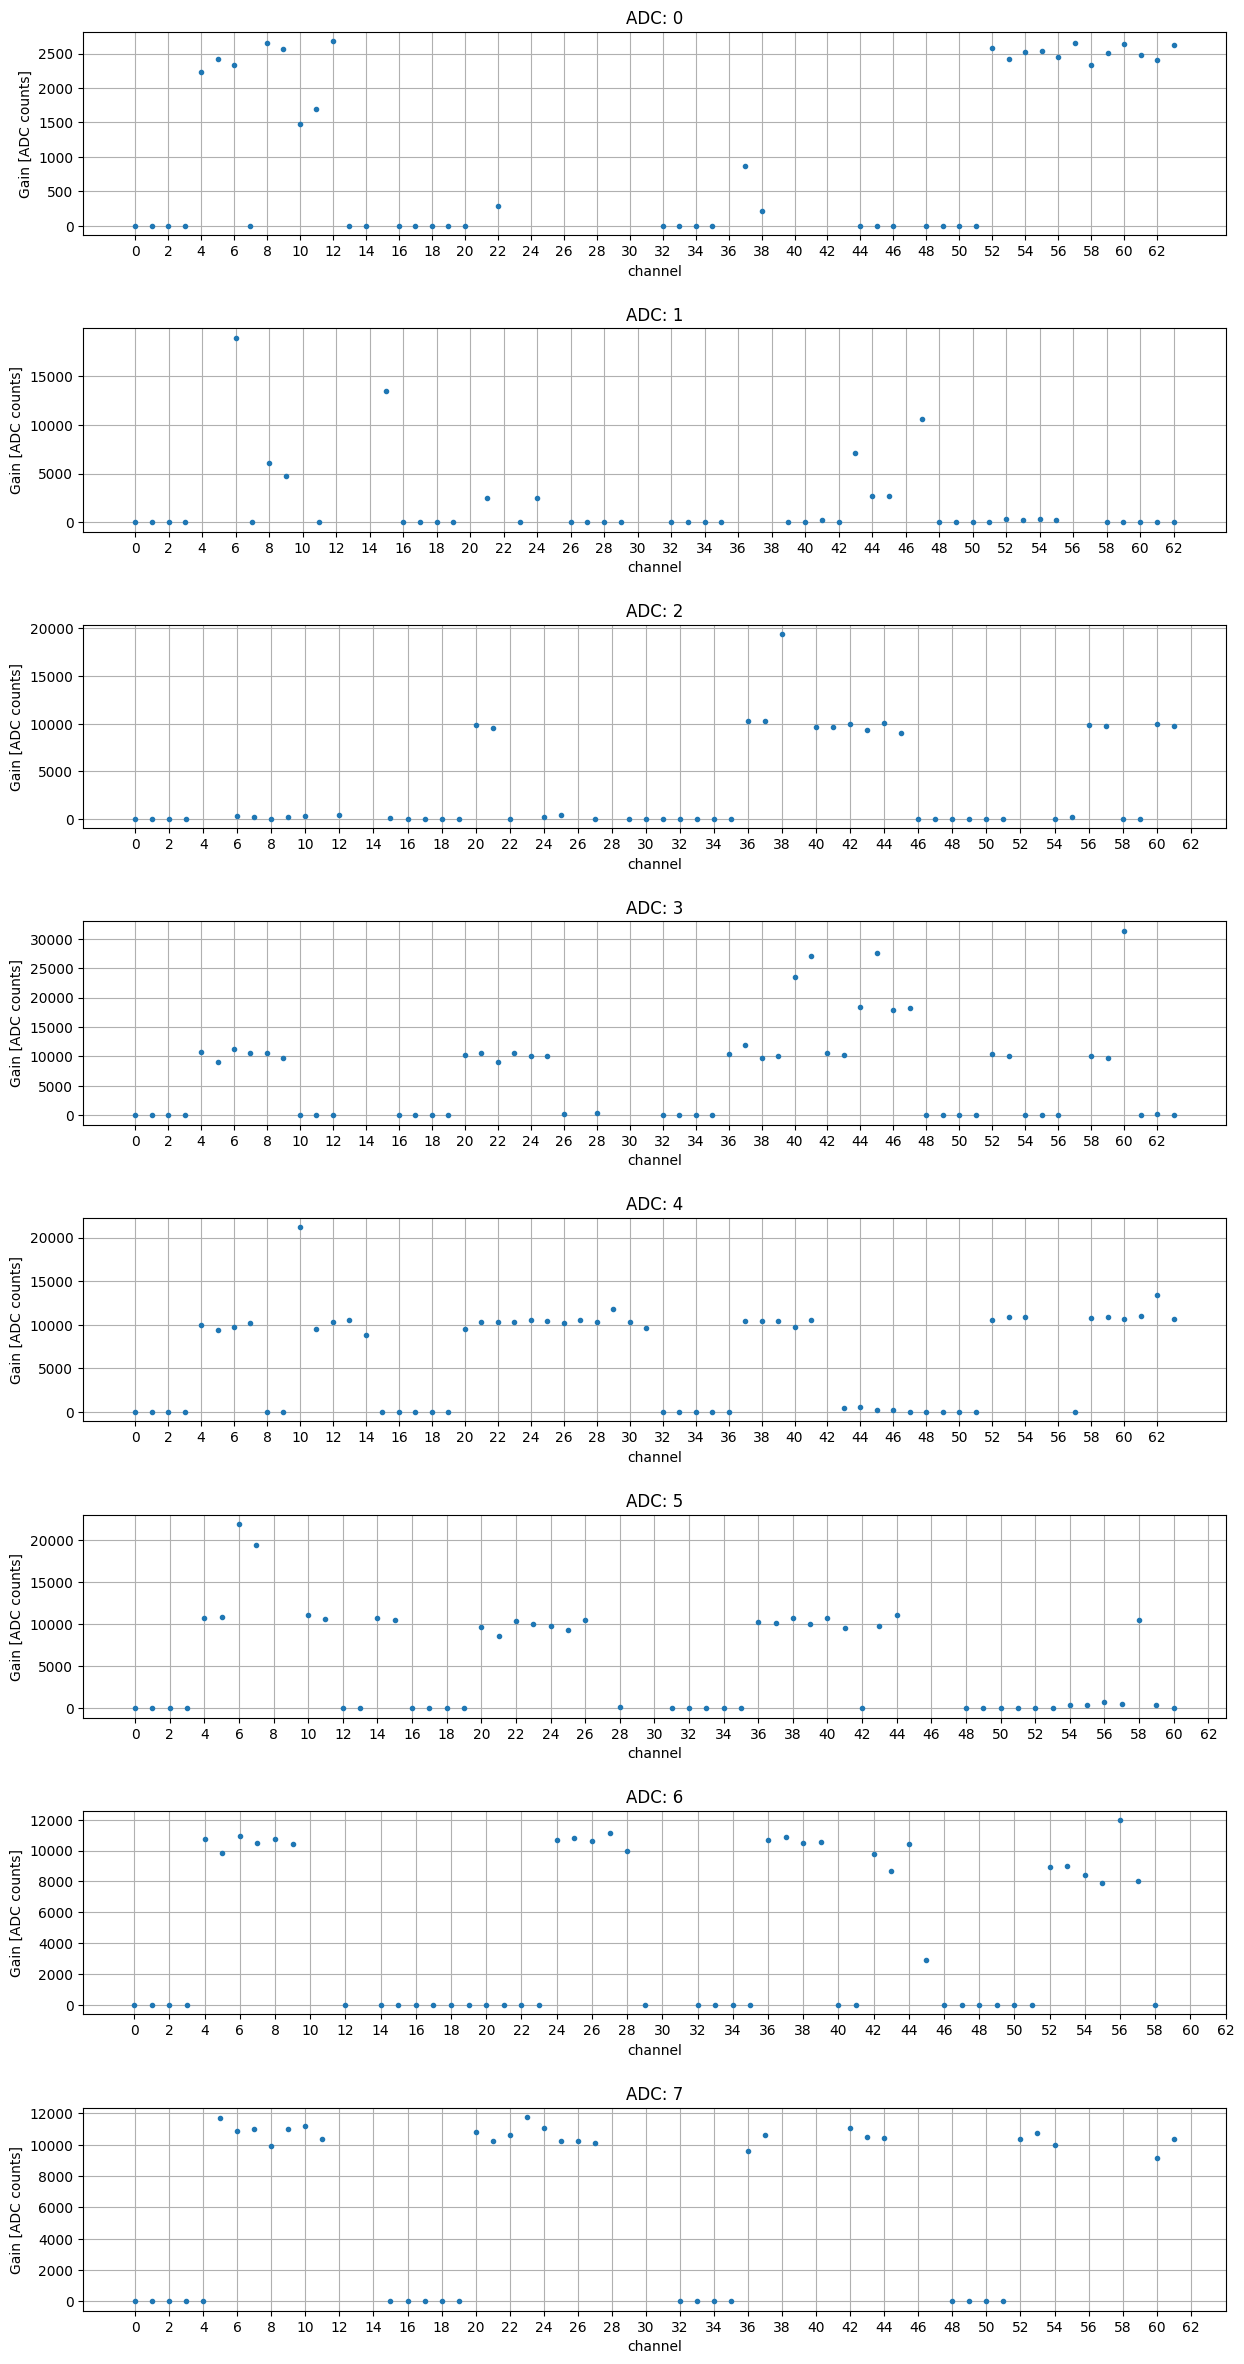

In [9]:
plot_gain(wvfms.gains)
